# Data_Preprocessing

## Step 0: Libraries

In [1]:
import pandas as pd
import re

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from pathlib import Path
from statsmodels.stats.outliers_influence import variance_inflation_factor

from collections import Counter

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks

from typing import Union

## Step 1: Conversion of gestational weeks units

### The data format of the "gestational age" column:

![](Images/picture1.png)

### First, convert it according to the formula in the paper:

![](Images/picture2.png)

In [5]:
def convert_gestational_age(value):
    """
    将检测孕周转换为小数
    """
    if isinstance(value, str):
        value = value.strip()
        # 匹配 "11w+6" 或 "11W+6"
        match_plus = re.match(r"(\d+)[wW]\+(\d+)", value)
        if match_plus:
            weeks = int(match_plus.group(1))
            days = int(match_plus.group(2))
            return round(weeks + days / 7, 2)

        # 匹配 "13w" 或 "13W"
        match_week = re.match(r"(\d+)[wW]", value)
        if match_week:
            return int(match_week.group(1))

    return value

### However, using Pandas brings about a problem:
Pandas or Excel automatically identifies "dates" as the datetime type,
and since datetime by default requires a time component, it will automatically pad it with 00:00:00.
To avoid this problem, a new function is required.

In [6]:
def clean_last_menstruation(value):
    """
    清理“末次月经”列:
        datetime → 'YYYY/MM/DD'
        '2023/2/1 0:00:00' → '2023/2/1'
    """
    if pd.isna(value):
        return value  # 保留空值

    # 如果是 datetime 类型
    if hasattr(value, "strftime"):
        return value.strftime("%Y/%m/%d")

    # 如果是字符串
    if isinstance(value, str):
        return value.replace(" 0:00:00", "").strip()

    return str(value)  # 其它情况强制转为字符串

### Finally, we will write a general function.
According to the requirements of the question, we will consider the data in the "Y chromosome concentration" column with a value greater than 0.04 as being accurately "NIPT test" results.

In [7]:
def process_excel(input_file, output_file):
    # 读取“男胎检测数据”工作表
    df = pd.read_excel(input_file, sheet_name="男胎检测数据")

    # 生成“NIPT准确性”列
    df["NIPT准确性"] = df["Y染色体浓度"].apply(lambda x: "是" if x > 0.04 else "否")

    # 转换“检测孕周”列
    if "检测孕周" in df.columns:
        df["检测孕周"] = df["检测孕周"].apply(convert_gestational_age)

    # 清理“末次月经”列
    if "末次月经" in df.columns:
        df["末次月经"] = df["末次月经"].apply(clean_last_menstruation)

    # 保存到新的 Excel 文件
    df.to_excel(output_file, index=False)
    print(f"处理完成，保存为: {output_file}")

In [8]:
if __name__ == "__main__":
    input_path = "../Data/附件.xlsx"  # 输入文件路径
    output_path = "../Data/男胎检测数据_处理后.xlsx"  # 输出文件路径
    process_excel(input_path, output_path)

处理完成，保存为: ../Data/男胎检测数据_处理后.xlsx


## Step 2: Missing Value Handling

### Missing value plotting function

In [10]:
def plot_missing_bar(series, title, y_label, save_path, xtick_step=200):
    """
    缺失值柱状图绘制函数
    """
    arr = series.isna().astype(int).to_numpy()[None, :]
    cmap = ListedColormap(["#1f77b4", "#d62728"])

    fig, ax = plt.subplots(figsize=(12, 2.5))
    ax.imshow(arr, aspect="auto", cmap=cmap, vmin=0, vmax=1)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Index", fontsize=12)
    ax.set_yticks([0])
    ax.set_yticklabels([y_label], fontsize=12)

    # Add index ticks
    n = len(series)
    xticks = np.arange(0, n, xtick_step)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, rotation=45, fontsize=9)

    # Legend
    legend_elements = [
        Patch(facecolor="#1f77b4", label="Present"),
        Patch(facecolor="#d62728", label="Missing")
    ]
    ax.legend(handles=legend_elements, loc="upper right",
              bbox_to_anchor=(1.0, 1.6), ncol=2, frameon=False)

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

### General function for missing value

In [11]:
path = "../Data/附件.xlsx"
male = pd.read_excel(path, sheet_name="男胎检测数据")
female = pd.read_excel(path, sheet_name="女胎检测数据")

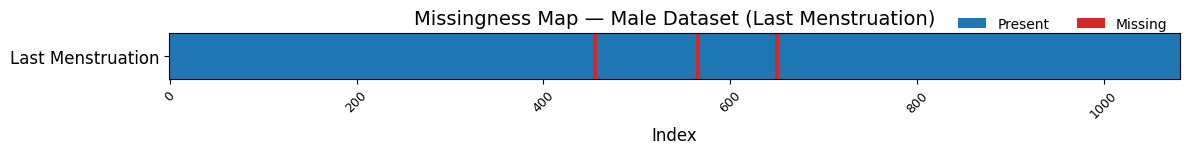

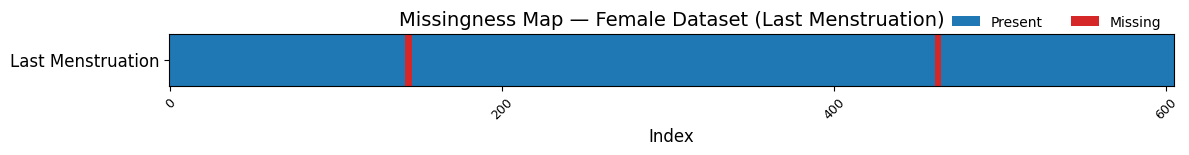

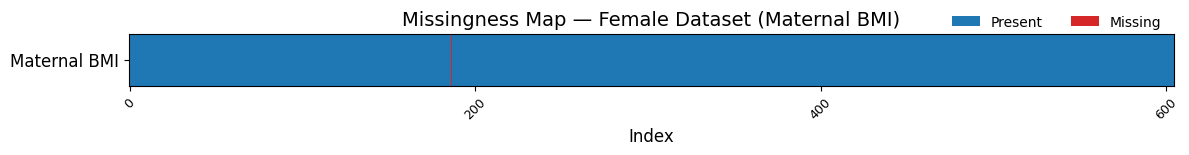

In [12]:
# 男胎数据集——末次月经缺失值
plot_missing_bar(
    male["末次月经"],
    title="Missingness Map — Male Dataset (Last Menstruation)",
    y_label="Last Menstruation",
    save_path="./Images/picture3.png"
)

# 女胎数据集——末次月经缺失值
plot_missing_bar(
    female["末次月经"],
    title="Missingness Map — Female Dataset (Last Menstruation)",
    y_label="Last Menstruation",
    save_path="./Images/picture4.png"
)

# 女胎数据集——BMI缺失值
plot_missing_bar(
    female["孕妇BMI"],
    title="Missingness Map — Female Dataset (Maternal BMI)",
    y_label="Maternal BMI",
    save_path="./Images/picture5.png"
)

### Final handling of missing values:
Since the indicators of the last menstrual period can be indirectly reflected by the gestational weeks, and their importance is low,
therefore, no processing is carried out on them here.
At the same time, for the case where the BMI of one sample is missing, it is restored by using the height-weight calculation formula.


## Step 3: Outlier handling

### Outlier handling follows the formula shown in the following figure.

![](Images/picture6.png)


### The code for outlier detection and box plotting is as follows:

In [26]:
file_path = "../Data/男胎检测数据_处理后.xlsx"
df = pd.read_excel(file_path)

cols = [
    "年龄",
    "身高",
    "体重",
    "孕妇BMI",
    "检测孕周",
    "GC含量",
    "13号染色体的Z值",
    "18号染色体的Z值",
    "21号染色体的Z值"
]

In [30]:
outlier_info = {}

for col in cols:
    # data = df[col].dropna()  # 去掉缺失值
    data = df[col]
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # 异常值
    outliers = data[(data < lower) | (data > upper)]
    num_outliers = outliers.shape[0]
    pct_outliers = num_outliers / data.shape[0] * 100

    outlier_info[col] = (num_outliers, pct_outliers)

    # 异常值位置输出到控制台（太长，注释算了）
    # print(f"{col}: 异常值 {num_outliers} 个，占 {pct_outliers:.2f}%")
    # print(outliers)

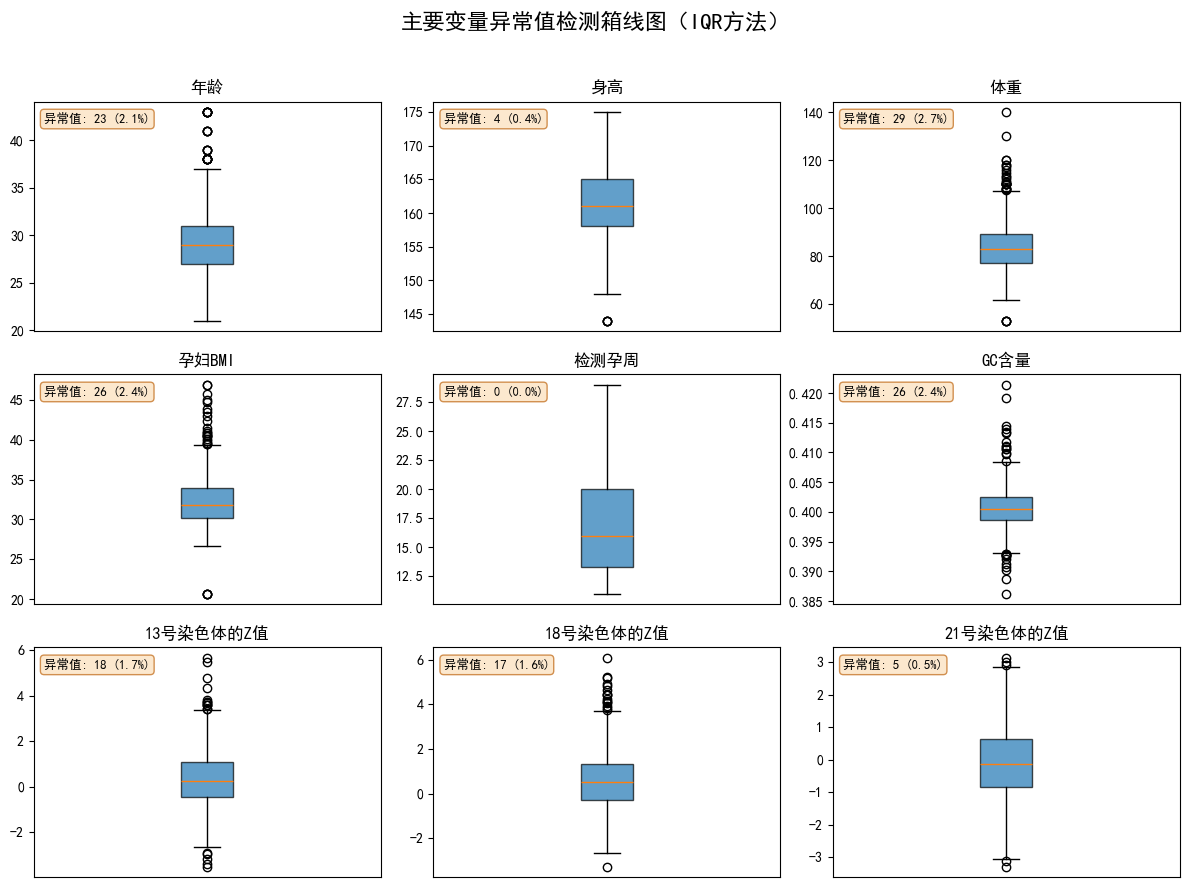

In [28]:
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
fig.suptitle("主要变量异常值检测箱线图（IQR方法）", fontsize=16, y=0.98)

for i, col in enumerate(cols):
    ax = axes[i // 3, i % 3]

    # 当前变量数据
    data = df[col].dropna()

    # 画箱线图
    bp = ax.boxplot(
        data,
        vert=True,
        showfliers=True,    # 显示异常值点
        patch_artist=True   # 允许填充颜色
    )

    # 简单设置一下箱体颜色（可省略）
    for patch in bp['boxes']:
        patch.set_alpha(0.7)

    ax.set_title(col, fontsize=12)
    ax.set_xticks([])  # 横轴刻度去掉，只保留箱线图

    # 添加异常值数量和比例标注
    n_out, pct_out = outlier_info[col]
    label = f"异常值: {n_out} ({pct_out:.1f}%)"
    ax.text(
        0.03, 0.95, label,
        transform=ax.transAxes,
        fontsize=9,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.3", fc="#fce6c9", ec="peru", alpha=0.9)
    )

plt.tight_layout(rect=[0, 0, 1, 0.96])  # 给总标题留一点空间
plt.savefig("./Images/picture7.png", dpi=300, bbox_inches="tight")
plt.show()

### Output abnormal value statistics table

In [29]:
print("\n" + "="*60)
print("异常值检测结果统计（IQR 方法）")
print("="*60)

# 打印表头
print(f"{'特征名称':<12}{'异常值数量':<12}{'异常值比例(%)':<14}{'Q1':<10}{'Q3':<10}{'IQR'}")

for col in cols:
    data = df[col].dropna()

    # 计算四分位数 & IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    # 异常值数量 & 比例
    num_outliers, pct_outliers = outlier_info[col]

    print(f"{col:<12}{num_outliers:<12}{pct_outliers:<14.2f}{q1:<10.2f}{q3:<10.2f}{iqr:.2f}")



异常值检测结果统计（IQR 方法）
特征名称        异常值数量       异常值比例(%)      Q1        Q3        IQR
年龄          23          2.13          27.00     31.00     4.00
身高          4           0.37          158.00    165.00    7.00
体重          29          2.68          77.01     89.09     12.08
孕妇BMI       26          2.40          30.21     33.93     3.72
检测孕周        0           0.00          13.29     20.00     6.71
GC含量        26          2.40          0.40      0.40      0.00
13号染色体的Z值   18          1.66          -0.48     1.07      1.55
18号染色体的Z值   17          1.57          -0.27     1.34      1.60
21号染色体的Z值   5           0.46          -0.86     0.63      1.49


In the replicated results here, the number and proportion of outliers are consistent, indicating that they are basically correct.
As for the slight mismatch between Q1/Q3/IQR, it might be due to different choices in interpolation, or it could be a difference between the statistical software/programming language.
This does not significantly affect the rigor of the paper and the project.


### The result table of the original paper is as follows:

![](Images/picture8.png)

## Step 4: Data Cleaning

### The qualified indicators for the quality assessment of sequencing data are as follows.

![](Images/picture9.png)


### The code for data cleaning based on the above indicators is as follows:


In [3]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
file_path = '../Data/附件.xlsx'

male_df = pd.read_excel(file_path, sheet_name='男胎检测数据')
female_df = pd.read_excel(file_path, sheet_name='女胎检测数据')

male_gc = pd.to_numeric(male_df['GC含量'], errors='coerce').dropna()
female_gc = pd.to_numeric(female_df['GC含量'], errors='coerce').dropna()

In [4]:
GC_LOW = 0.4
GC_HIGH = 0.6

# 定义一个通用绘图函数
def plot_gc_qc(ax_row, gc_series, label, bins_size1 = None, bins_size2 = None):
    """
    ax_row: axes[行索引, :]，长度为3的一行Axes
    gc_series: 该表的GC含量Series
    label: '男胎' 或 '女胎'
    """
    total = len(gc_series)
    mask_ok = (gc_series >= GC_LOW) & (gc_series <= GC_HIGH)
    keep_gc = gc_series[mask_ok]
    keep_count = mask_ok.sum()
    drop_count = total - keep_count
    keep_ratio = keep_count / total
    drop_ratio = drop_count / total

    # 过滤前直方图
    ax1 = ax_row[0]
    ax1.hist(gc_series, bins=bins_size1, color='#d9d9d9', edgecolor='black')
    ax1.axvline(GC_LOW, color='red', linestyle='--', linewidth=1.5, label='40%下限')
    ax1.axvline(GC_HIGH, color='red', linestyle='--', linewidth=1.5, label='60%上限')
    ax1.set_title(f'{label}GC含量分布（过滤前）')
    ax1.set_xlabel('GC含量')
    ax1.set_ylabel('频数')
    ax1.set_xlim(0.35, 0.65)
    ax1.legend()

    # 过滤后直方图
    ax2 = ax_row[1]
    ax2.hist(keep_gc, bins=bins_size2, color='#99d98c', edgecolor='black')
    ax2.set_title(f'{label}GC含量分布（过滤后）')
    ax2.set_xlabel('GC含量')
    ax2.set_ylabel('频数')
    # 过滤后 x 轴稍微缩小一点范围
    if not keep_gc.empty:
        ax2.set_xlim(max(keep_gc.min() - 0.002, 0), keep_gc.max() + 0.002)

    # 饼图
    ax3 = ax_row[2]
    sizes = [keep_count, drop_count]
    labels = ['保留', '过滤']
    colors = ['#8fd175', '#ff6f69']
    explode = (0.03, 0)

    wedges, texts, autotexts = ax3.pie(
        sizes,
        labels=labels,
        autopct='%.1f%%',
        startangle=90,
        colors=colors,
        explode=explode,
        textprops={'fontsize': 10}
    )
    ax3.set_title(f'{label}样本过滤结果\n({keep_count}/{total})')
    ax3.axis('equal')  # 让饼图为正圆

    # 在控制台打印统计信息
    print(f'[{label}] 总样本数: {total}')
    print(f'[{label}] 保留样本数: {keep_count} ({keep_ratio:.2%})')
    print(f'[{label}] 过滤样本数: {drop_count} ({drop_ratio:.2%})')
    print('-' * 40)

[男胎] 总样本数: 1082
[男胎] 保留样本数: 631 (58.32%)
[男胎] 过滤样本数: 451 (41.68%)
----------------------------------------
[女胎] 总样本数: 605
[女胎] 保留样本数: 385 (63.64%)
[女胎] 过滤样本数: 220 (36.36%)
----------------------------------------


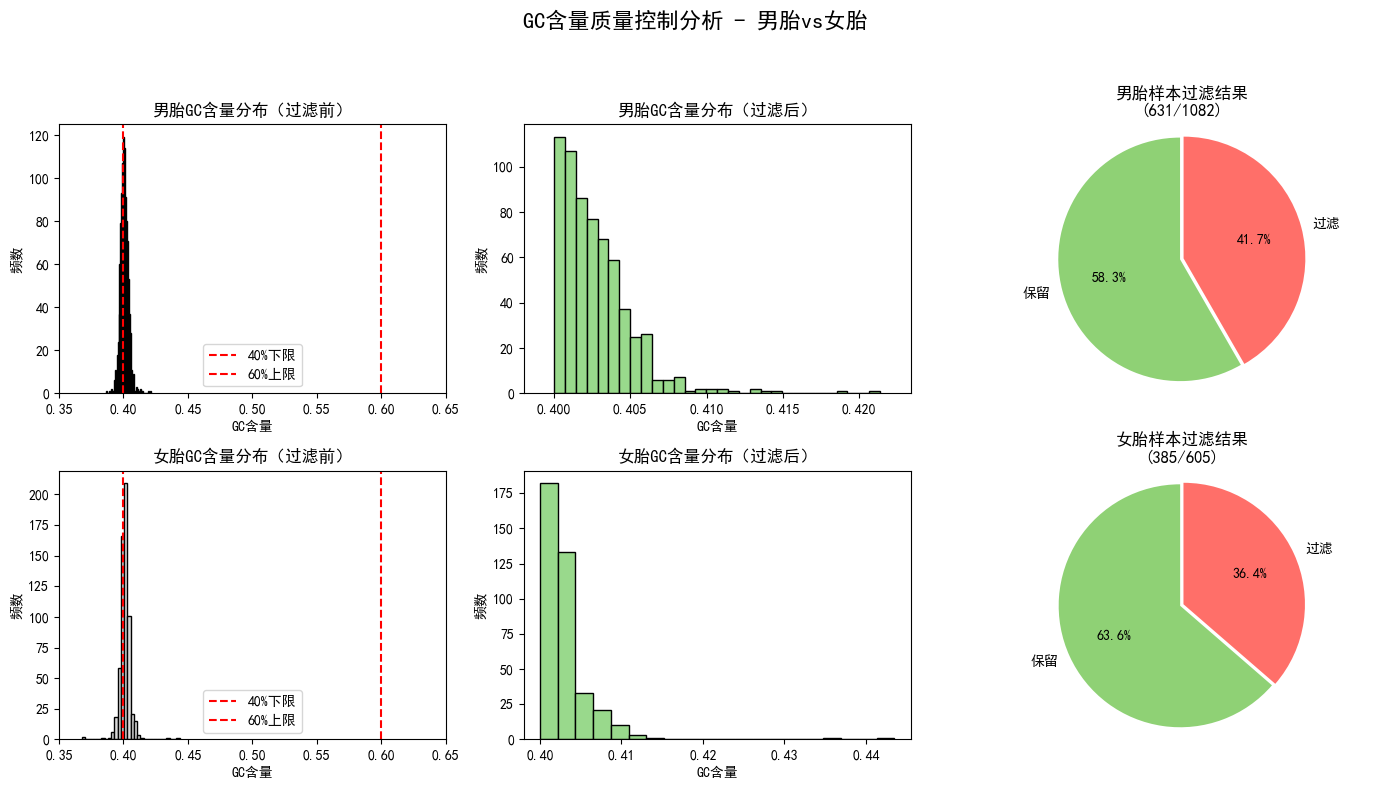

In [5]:
# 生成六合一图
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# 男胎
plot_gc_qc(axes[0, :], male_gc, '男胎', 46, 30)
# 女胎
plot_gc_qc(axes[1, :], female_gc, '女胎', 30, 20)

fig.suptitle('GC含量质量控制分析 - 男胎vs女胎', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# 保存图片
plt.savefig('./Images/picture10.png', dpi=300, bbox_inches='tight')
plt.show()

### The result picture of the original paper is as follows:

![](Images/picture12.png)

![](Images/picture11.png)

The two are exactly the same.

## Step 5: Female fetus data VIF multicollinearity test

### The function for the multicollinearity test of Female fetus data are as follows.

![](Images/picture13.png)

### The code forVIF multicollinearity test based on the above function is as follows:


In [2]:
# 参数
INPUT_FILE = "../Data/附件.xlsx"
SHEET = "女胎检测数据"
TARGET_COL = "染色体是否正常0-1变量"
PREDICTOR_COLS = [
    "检测抽血次数", "检测孕周", "孕妇BMI", "原始读段数", "在参考基因组上比对的比例",
    "重复读段的比例", "唯一比对的读段数  ", "GC含量", "13号染色体的Z值", "18号染色体的Z值",
    "21号染色体的Z值", "X染色体的Z值", "X染色体浓度", "13号染色体的GC含量",
    "18号染色体的GC含量", "21号染色体的GC含量", "被过滤掉读段数的比例"
]
VIF_THRESHOLD = 10.0
OUTPUT_FILE = "../Data/VIF_Example_Female.xlsx"

In [3]:
# 由于这里使用的是原始数据集的数据，所以还要经过数据清洗
def to_weeks(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    s = str(val).strip()
    # 13w+5 / 13W+5
    m = re.match(r"^\s*(\d+)\s*[wW]\s*\+\s*(\d+)\s*$", s)
    if m:
        return round(int(m.group(1)) + int(m.group(2)) / 7.0, 2)
    # 13w / 13W
    m = re.match(r"^\s*(\d+)\s*[wW]\s*$", s)
    if m:
        return float(m.group(1))
    # 纯数字字符串
    m = re.match(r"^\s*(\d+(\.\d+)?)\s*$", s)
    if m:
        return float(m.group(1))
    return np.nan


def to_numeric_maybe_percent(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return float(x)
    s = str(x).strip()
    # 百分号
    if s.endswith("%"):
        try:
            return float(s[:-1]) / 100.0
        except:
            return np.nan
    # 普通数字
    try:
        return float(s)
    except:
        return np.nan


In [4]:
def find_sheet_with_columns(xls: pd.ExcelFile, required_cols: list[str]) -> str:
    best_sheet = None
    best_score = -1
    for sheet in xls.sheet_names:
        df_tmp = pd.read_excel(xls, sheet_name=sheet, nrows=5)
        cols = set(df_tmp.columns)
        score = len(cols.intersection(set(required_cols)))
        if score > best_score:
            best_sheet, best_score = sheet, score
    return best_sheet


def compute_vif_table(x: pd.DataFrame) -> pd.DataFrame:
    """
    计算当前自变量矩阵的 VIF 表。
    """
    arr = x.values
    vif_list = []
    for i in range(arr.shape[1]):
        vif_val = variance_inflation_factor(arr, i)
        vif_list.append(vif_val)
    return pd.DataFrame({"feature": x.columns, "VIF": vif_list}).sort_values("VIF", ascending=False)


def stepwise_vif_selection(x: pd.DataFrame, threshold: float = 10.0, max_steps: int = 100):
    """
    逐步剔除法：
      - 计算各特征 VIF
      - 若最高 VIF > 阈值，则剔除该特征，继续
      - 直到全部 <= 阈值 或 达到 max_steps
    """
    kept_cols = list(x.columns)
    history = []
    dropped_order = []

    for step in range(max_steps):
        vif_df = compute_vif_table(x[kept_cols])
        history.append(vif_df.copy())

        max_row = vif_df.iloc[0]
        if max_row["VIF"] > threshold and len(kept_cols) > 1:
            drop_col = max_row["feature"]
            dropped_order.append(drop_col)
            kept_cols.remove(drop_col)
            # 下一轮继续
        else:
            break

    final_vif = compute_vif_table(x[kept_cols])
    return x[kept_cols].copy(), final_vif, history, dropped_order

In [8]:
def main():
    # 0) 读取工作簿并定位工作表
    xls = pd.ExcelFile(INPUT_FILE)
    required_any = [TARGET_COL] + PREDICTOR_COLS
    # sheet = find_sheet_with_columns(xls, required_any)
    # if sheet is None:
    #     raise RuntimeError("未能在工作簿中找到包含所需列的工作表，请检查列名。")

    df = pd.read_excel(xls, sheet_name=SHEET)
    print(f"使用工作表：{SHEET}")

    # 1) 新增“染色体是否正常”
    col_aneu = "染色体的非整倍体"
    if col_aneu not in df.columns:
        alt = [c for c in df.columns if "非整倍体" in str(c)]
        if alt:
            col_aneu = alt[0]
        else:
            df[col_aneu] = np.nan

    df["染色体是否正常"] = np.where(
        df[col_aneu].astype(str).str.strip().replace({"nan": ""}) == "",
        "是", "否"
    )

    df["染色体是否正常0-1变量"] = np.where(df["染色体是否正常"] == "是", 1, 0)

    # 1.5) 检查并提取列
    missing = [c for c in [TARGET_COL] + PREDICTOR_COLS if c not in df.columns]
    if missing:
        print("警告：下列列在此工作表中未找到，将忽略：", missing)

    cols_in = [c for c in PREDICTOR_COLS if c in df.columns]
    if len(cols_in) < 2:
        raise RuntimeError("可用的自变量少于 2 个，无法计算 VIF。请检查列名。")

    # 2) 复制出自变量矩阵 X，并做清洗/数值化
    X = df[cols_in].copy()

    # 2.1) 特殊处理 “检测孕周”
    if "检测孕周" in X.columns:
        X["检测孕周"] = X["检测孕周"].apply(to_weeks)

    # 2.2) 将可疑的百分号字符串/一般数值字符串 -> 数值
    percent_like_cols = [
        "在参考基因组上比对的比例", "重复读段的比例", "GC含量",
        "13号染色体的GC含量", "18号染色体的GC含量", "21号染色体的GC含量",
        "被过滤掉读段数的比例"
    ]
    for c in X.columns:
        if c in percent_like_cols or X[c].dtype == "object":
            X[c] = X[c].apply(to_numeric_maybe_percent)

    # 2.3) 全部转为数值
    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")

    # 3) 缺失值填补
    X = X.apply(lambda s: s.fillna(s.median()), axis=0)

    # 3.1) 若仍存在全为 NaN 的列，剔除该列
    all_na_cols = [c for c in X.columns if X[c].isna().all()]
    if all_na_cols:
        print("警告：以下列全部为缺失，已剔除：", all_na_cols)
        X = X.drop(columns=all_na_cols)

    # 4) 逐步 VIF 筛选
    kept_X, final_vif, history, dropped = stepwise_vif_selection(X, threshold=VIF_THRESHOLD, max_steps=200)

    # 5) 打印日志
    print("\n=== VIF 逐步筛选日志（每轮最高值在首行）===")
    for i, vif_df in enumerate(history, 1):
        top = vif_df.iloc[0]
        print(f"第 {i:02d} 轮：最高 VIF = {top['VIF']:.3f}（{top['feature']}）; 特征数={len(vif_df)}")

    if dropped:
        print("\n被剔除特征顺序：", " -> ".join(dropped))
    else:
        print("\n未剔除任何特征（均 <= 阈值）。")

    print("\n=== 最终保留特征及其 VIF ===")
    print(final_vif.to_string(index=False))

    # 6) 导出结果
    out_path = Path(OUTPUT_FILE).resolve()
    with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
        # 每一轮 VIF
        for i, vif_df in enumerate(history, 1):
            vif_df.to_excel(writer, sheet_name=f"round_{i:02d}_vif", index=False)
        # 最终 VIF
        final_vif.to_excel(writer, sheet_name="final_vif", index=False)
        # 剔除顺序
        pd.DataFrame({"dropped_order": dropped}).to_excel(writer, sheet_name="dropped_order", index=False)


In [9]:
if __name__ == "__main__":
    main()

使用工作表：女胎检测数据
警告：下列列在此工作表中未找到，将忽略： ['唯一比对的读段数  ']

=== VIF 逐步筛选日志（每轮最高值在首行）===
第 01 轮：最高 VIF = 442825.793（18号染色体的GC含量）; 特征数=16
第 02 轮：最高 VIF = 171106.093（13号染色体的GC含量）; 特征数=15
第 03 轮：最高 VIF = 5747.684（GC含量）; 特征数=14
第 04 轮：最高 VIF = 1975.960（21号染色体的GC含量）; 特征数=13
第 05 轮：最高 VIF = 258.417（在参考基因组上比对的比例）; 特征数=12
第 06 轮：最高 VIF = 190.863（检测孕周）; 特征数=11
第 07 轮：最高 VIF = 68.214（重复读段的比例）; 特征数=10
第 08 轮：最高 VIF = 31.513（孕妇BMI）; 特征数=9
第 09 轮：最高 VIF = 7.684（原始读段数）; 特征数=8

被剔除特征顺序： 18号染色体的GC含量 -> 13号染色体的GC含量 -> GC含量 -> 21号染色体的GC含量 -> 在参考基因组上比对的比例 -> 检测孕周 -> 重复读段的比例 -> 孕妇BMI

=== 最终保留特征及其 VIF ===
   feature      VIF
     原始读段数 7.683657
被过滤掉读段数的比例 6.053994
    检测抽血次数 5.326871
 18号染色体的Z值 2.148772
 13号染色体的Z值 1.650133
   X染色体的Z值 1.600666
    X染色体浓度 1.164995
 21号染色体的Z值 1.060291


## Step 6: Construction of the target variable for female-fetus data:
### A binary classification target is created based on the chromosomal aneuploidy detection results:
Abnormal: The value in column AB is non-empty, indicating that trisomy 13, 18, or 21 has been detected.
Normal: The value in column AB is empty, indicating that no chromosomal abnormalities have been detected.

In [10]:
in_path  = "..\Data\附件.xlsx"
sheet    = "女胎检测数据"
out_path = "..\Data\附件_女胎检测数据_处理后.xlsx"

In [11]:
# 工具
def to_weeks(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return round(float(value), 2)

    s = str(value).strip()
    m_plus = re.match(r"^\s*(\d+)\s*[wW]\s*\+\s*(\d+)\s*$", s)
    if m_plus:
        w = int(m_plus.group(1)); d = int(m_plus.group(2))
        return round(w + d/7.0, 2)

    m_w = re.match(r"^\s*(\d+)\s*[wW]\s*$", s)
    if m_w:
        return round(float(m_w.group(1)), 2)

    m_num = re.match(r"^\s*(\d+(?:\.\d+)?)\s*$", s)
    if m_num:
        return round(float(m_num.group(1)), 2)

    return np.nan

In [12]:
# 读取目标表
xl = pd.ExcelFile(in_path)
if sheet not in xl.sheet_names:
    raise ValueError(f"未找到工作表：{sheet}；现有工作表：{xl.sheet_names}")
df = pd.read_excel(in_path, sheet_name=sheet)

# 删除 U、V 两列
if df.shape[1] >= 22:
    cols_to_drop = []
    try:
        cols_to_drop.append(df.columns[20])  # U
        cols_to_drop.append(df.columns[21])  # V
    except Exception:
        cols_to_drop = []
    if cols_to_drop:
        df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# “染色体是否正常”
col_aneu = "染色体的非整倍体"
if col_aneu not in df.columns:
    alt = [c for c in df.columns if "非整倍体" in str(c)]
    if alt:
        col_aneu = alt[0]
    else:
        df[col_aneu] = np.nan

df["染色体是否正常"] = np.where(
    df[col_aneu].astype(str).str.strip().replace({"nan": ""}) == "",
    "是", "否"
)

df["染色体是否正常0-1变量"] = np.where(df["染色体是否正常"] == "是", 1, 0)

# 规范“检测孕周”
col_weeks = "检测孕周"
if col_weeks not in df.columns:
    alt = [c for c in df.columns if "孕周" in str(c)]
    if alt:
        col_weeks = alt[0]
    else:
        raise ValueError("未找到“检测孕周”列，也未识别到包含“孕周”的别名。")
df[col_weeks] = df[col_weeks].apply(to_weeks)

# “孕妇BMI”缺失均值填充
bmi_candidates = ["孕妇BMI", "BMI", "孕妇BM"]
bmi_col = None
for c in bmi_candidates:
    if c in df.columns:
        bmi_col = c
        break
if bmi_col is None:
    if {"身高", "体重"}.issubset(df.columns):
        df["孕妇BMI"] = df["体重"] / (df["身高"] / 100.0) ** 2
        bmi_col = "孕妇BMI"
    else:
        raise ValueError("未找到“孕妇BMI/BMI/孕妇BM”，且无法由身高/体重计算。")
df[bmi_col] = pd.to_numeric(df[bmi_col], errors="coerce")
df[bmi_col] = df[bmi_col].fillna(df[bmi_col].mean(skipna=True))

# 复制“GC含量”为“原GC含量”
gc_col = "GC含量"
if gc_col not in df.columns:
    alt = [c for c in df.columns if "GC" in str(c) and "含量" in str(c) and "染色体" not in str(c)]
    if alt:
        gc_col = alt[0]
    else:
        raise ValueError("未找到“GC含量”列。")
df["原GC含量"] = df[gc_col]

# 复制“检测孕周”“孕妇BMI”为备份列
df["原检测孕周"] = df[col_weeks]
df["原孕妇BMI"] = df[bmi_col]
if "末次月经" in df.columns:
    df["末次月经"] = pd.to_datetime(df["末次月经"], errors="coerce").dt.date

# 保存
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name=sheet, index=False)

print(f"处理完成！已保存：{out_path}")

处理完成！已保存：..\Data\附件_女胎检测数据_处理后.xlsx


## Step 7: Combined sample equalization processing:
### For the proportion of abnormal samples of 11.4% in the female fetal data, a combined strategy of SMOTE oversampling and Tomek Links undersampling is adopted here.

First, we compute the class distribution of the binary label and identify the minority and majority classes. SMOTE is then configured so that only the minority class is over-sampled: the sampling strategy sets the target number of minority samples equal to the number of majority samples, and the number of nearest neighbors k is automatically chosen based on the minority class size (capped at 5). SMOTE generates synthetic minority samples by interpolating between each minority instance and its nearest minority neighbors in feature space, until the minority class size matches that of the majority class.

After this over-sampling step, we apply Tomek Links as a targeted under-sampling method. A Tomek link is defined as a pair of samples from different classes that are each other’s nearest neighbors, typically lying near the decision boundary.

In our implementation, Tomek Links is configured to remove only the minority-class samples involved in such pairs, while preserving all majority-class samples. This design choice ensures that under-sampling never deletes majority-class instances, because the majority class consists entirely of real observations, whereas the minority class has just been enlarged through synthetic SMOTE samples. As a result, Tomek Links acts only to clean noisy or borderline minority points, yielding a dataset that remains approximately balanced but exhibits a clearer and more reliable class boundary for subsequent modeling.

In [2]:
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'STSong']
plt.rcParams['axes.unicode_minus'] = False

INPUT_FILE   = "../Data/附件_女胎检测数据_处理后.xlsx"
sheet = "女胎检测数据"
TARGET_COL   = "染色体是否正常0-1变量"
STATUS_COL   = "染色体是否正常"

PREDICTOR_COLS = []

RANDOM_STATE  = 42
OUTPUT_FILE   = "../Data/balanced_组合采样.xlsx"
OUTPUT_FILE_EXAMPLE = "../Data/balanced_组合采样_example.xlsx"

In [3]:
# 将一些奇奇怪怪的数字格式统统转成SMOTE/Tomek可以使用的
def to_numeric_maybe_percent(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)):
        return float(x)
    s = str(x).strip()
    if s.endswith("%"):
        try:
            return float(s[:-1]) / 100.0
        except:
            return np.nan
    try:
        return float(s)
    except:
        return np.nan

# 去掉NAN INF 全空列这种
def robust_numeric_cleanup(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    X = X.replace([np.inf, -np.inf], np.nan)

    all_nan_cols = [c for c in X.columns if X[c].isna().all()]
    if all_nan_cols:
        X = X.drop(columns=all_nan_cols)

    med = X.median(numeric_only=True)
    X = X.apply(lambda s: s.fillna(med.get(s.name, np.nan)))

    still_all_nan = [c for c in X.columns if X[c].isna().all()]
    if still_all_nan:
        X[still_all_nan] = X[still_all_nan].fillna(0.0)

    return X

In [4]:
# “组合采样 + 导出”封装成函数
def combo_sample_and_export(
        X: pd.DataFrame,
        y: pd.Series,
        output_file: str,
        status_col: str,
        verbose_tag: str = "",
        plot_info: Union[dict, None] = None
):
    """
    1）SMOTE 只对少数类过采样到多数类一样多；
    2）TomekLinks 只在少数类上做清理（删掉一部分少数类），不删多数类。
    """

    tag = f"[{verbose_tag}]" if verbose_tag else ""

    # 组合采样前类别分布
    cnt_before = Counter(y)
    print(f"\n{tag} 组合采样之前类别分布：", dict(cnt_before))

    # 识别多数类 / 少数类
    minority_class = min(cnt_before, key=cnt_before.get)
    majority_class = max(cnt_before, key=cnt_before.get)
    minority_n = cnt_before[minority_class]
    majority_n = cnt_before[majority_class]

    # 根据少数类自动设置 SMOTE 的 k_neighbors
    k_neighbors = max(1, min(5, minority_n - 1))
    if k_neighbors < 1:
        raise RuntimeError(f"{tag} 少数类样本太少，无法进行 SMOTE（需要至少 2 个少数类样本）。")
    print(f"{tag} SMOTE 使用 k_neighbors={k_neighbors}（少数类样本数={minority_n}）")

    # SMOTE 过采样
    smote_strategy = {minority_class: majority_n}
    smote = SMOTE(
        sampling_strategy=smote_strategy,
        k_neighbors=k_neighbors,
        random_state=RANDOM_STATE
    )

    X_sm, y_sm = smote.fit_resample(X, y)
    cnt_after_smote = Counter(y_sm)
    print(f"{tag} SMOTE 之后类别分布：", dict(cnt_after_smote))

    # Tomek Links 欠采样，只删掉少数类
    tomek = TomekLinks(sampling_strategy=[minority_class])
    X_res, y_res = tomek.fit_resample(X_sm, y_sm)

    # 组合采样后类别分布
    cnt_after = Counter(y_res)
    print(f"{tag} TomekLinks 之后类别分布：", dict(cnt_after))

    # 加入目标列与“染色体是否正常”同步列
    df_res = pd.concat([X_res.reset_index(drop=True),
                        pd.Series(y_res, name=TARGET_COL)], axis=1)

    df_res[status_col] = df_res[TARGET_COL].map({1: "是", 0: "否"}).astype(object)

    out_path = Path(output_file).resolve()
    df_res.to_excel(out_path, index=False)
    print(f"\n{tag} 已导出均衡数据：{out_path}")

    # 画图
    if plot_info is not None:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(plot_info.get("title", "女胎数据建模准备流程分析"), fontsize=14)

        # 图 1：采样前类别饼图
        normal_before = cnt_before.get(1, 0)
        abnormal_before = cnt_before.get(0, 0)
        axes[0].pie(
            [normal_before, abnormal_before],
            labels=["正常", "异常"],
            autopct="%.1f%%",
            startangle=90
        )
        axes[0].set_title(f"原始类别分布（{normal_before + abnormal_before} 样本）")

        # 图 2：采样后类别饼图
        normal_after = cnt_after.get(1, 0)
        abnormal_after = cnt_after.get(0, 0)
        axes[1].pie(
            [normal_after, abnormal_after],
            labels=["正常", "异常"],
            autopct="%.1f%%",
            startangle=90
        )
        axes[1].set_title(f"平衡后类别分布（{normal_after + abnormal_after} 样本）")

        plt.tight_layout(rect=[0, 0, 1, 0.9])

        fig.savefig("./Images/picture14.png",
                        dpi=300, bbox_inches="tight")

        plt.show()

使用工作表：女胎检测数据

[原始数据] 组合采样之前类别分布： {1: 538, 0: 67}
[原始数据] SMOTE 使用 k_neighbors=5（少数类样本数=67）


E:\anaconda3\envs\new1torch270cu128\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


[原始数据] SMOTE 之后类别分布： {1: 538, 0: 538}
[原始数据] TomekLinks 之后类别分布： {1: 538, 0: 531}


E:\anaconda3\envs\new1torch270cu128\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



[原始数据] 已导出均衡数据：D:\LearningDeepLearning\2025Modeling\NoteBook\Data\balanced_组合采样.xlsx

[GC过滤] 总样本数： 605
[GC过滤] 保留 GC∈[0.4,0.6] 的样本数： 385

[GC∈[0.4,0.6] 过滤后] 组合采样之前类别分布： {1: 341, 0: 44}
[GC∈[0.4,0.6] 过滤后] SMOTE 使用 k_neighbors=5（少数类样本数=44）
[GC∈[0.4,0.6] 过滤后] SMOTE 之后类别分布： {1: 341, 0: 341}
[GC∈[0.4,0.6] 过滤后] TomekLinks 之后类别分布： {1: 341, 0: 330}


E:\anaconda3\envs\new1torch270cu128\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
E:\anaconda3\envs\new1torch270cu128\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



[GC∈[0.4,0.6] 过滤后] 已导出均衡数据：D:\LearningDeepLearning\2025Modeling\NoteBook\Data\balanced_组合采样_example.xlsx


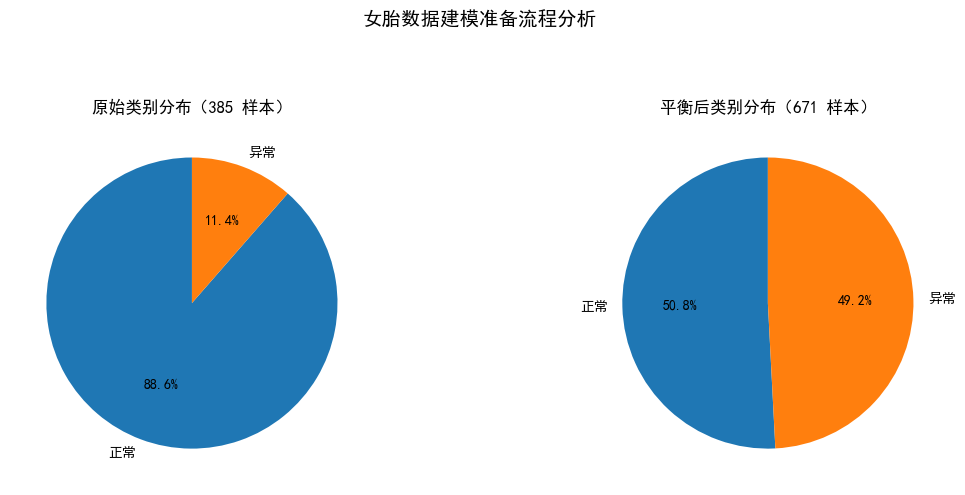

In [5]:
def main():
    xls = pd.ExcelFile(INPUT_FILE)
    df = pd.read_excel(xls, sheet_name=sheet)
    print(f"使用工作表：{sheet}")

    if TARGET_COL not in df.columns:
        raise RuntimeError(f"当前工作表不含目标列：{TARGET_COL}")

    def to01(v):
        if pd.isna(v):
            return np.nan
        if isinstance(v, (int, float)):
            return int(v)
        s = str(v).strip()
        if s in ["1", "是", "true", "True", "TRUE"]:
            return 1
        if s in ["0", "否", "false", "False", "FALSE"]:
            return 0
        try:
            f = float(s)
            return int(round(f))
        except:
            return np.nan

    y = df[TARGET_COL].map(to01)
    if y.isna().any():
        bad_rows = y[y.isna()].index.tolist()[:10]
        raise ValueError(
            f"目标列存在无法转为0/1的值，示例行索引：{bad_rows}（最多显示10行）。请先清洗后再运行。"
        )

    if PREDICTOR_COLS:
        missing = [c for c in PREDICTOR_COLS if c not in df.columns]
        if missing:
            print("警告：以下指定特征列不存在，将忽略：", missing)
        X = df[[c for c in PREDICTOR_COLS if c in df.columns]].copy()
    else:
        X = df.drop(columns=[TARGET_COL]).copy()

    percent_like_cols = {
        "在参考基因组上比对的比例", "重复读段的比例", "GC含量",
        "13号染色体的GC含量", "18号染色体的GC含量", "21号染色体的GC含量",
        "被过滤掉读段数的比例"
    }
    for c in X.columns:
        if c in percent_like_cols or X[c].dtype == "object":
            X[c] = X[c].apply(to_numeric_maybe_percent)

    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")

    X_numeric_before_cleanup = X.copy()
    X_clean = robust_numeric_cleanup(X)
    n_total = len(X_clean)

    # 原始数据直接组合采样（不画图）
    combo_sample_and_export(
        X_clean,
        y,
        OUTPUT_FILE,
        STATUS_COL,
        verbose_tag="原始数据"
    )

    # GC 过滤后再采样 + 画两个饼图
    if "GC含量" not in X_numeric_before_cleanup.columns:
        print("\n[警告] X 中不存在列 'GC含量'，无法生成 balanced_组合采样_example.xlsx")
        return

    gc_series = X_numeric_before_cleanup["GC含量"]
    mask_gc_ok = gc_series.between(0.4, 0.6, inclusive="both")

    print("\n[GC过滤] 总样本数：", len(gc_series))
    print("[GC过滤] 保留 GC∈[0.4,0.6] 的样本数：", mask_gc_ok.sum())

    X_gc = X_numeric_before_cleanup[mask_gc_ok].copy()
    y_gc = y[mask_gc_ok].copy()
    n_gc = len(y_gc)

    if len(y_gc.unique()) < 2:
        raise RuntimeError("GC过滤后只剩下单一类别，无法进行组合采样。请检查数据或放宽过滤条件。")

    X_gc_clean = robust_numeric_cleanup(X_gc)

    plot_info = {
        "title": "女胎数据建模准备流程分析",
        "n_orig_total": n_total,
        "n_after_gc": n_gc,
        "n_after_selection": n_gc
    }

    combo_sample_and_export(
        X_gc_clean,
        y_gc,
        OUTPUT_FILE_EXAMPLE,
        STATUS_COL,
        verbose_tag="GC∈[0.4,0.6] 过滤后",
        plot_info=plot_info
    )

if __name__ == "__main__":
    main()


### The result picture of the original paper is as follows:

![](Images/picture15.png)